# HDBSCAN & DBSCAN Analysis

* **DBSCAN** is a density based clustering algorithm. Instead of guessing how many clusters are needed, we define the hyperparameters ∈ and 𝑛.
The advantage of DBSCAN is that it can build clusters that have an arbitrary shape, while k-means and other centroid-based algorithms create clusters that have a shape of a hypersphere. The drawback is that it has 2 hyperparameters and choosing good values for them (especially ∈) can be challenging. Also, with a fixed ∈, the clustering algorithm cannot effectively deal with clusters of varying density.

* **HDBSCAN** has the same advantages as DBSCAN but only has 1 hyperparameter (𝑛). It can build clusters of varying density. 
  * 𝑛: the minimum number of examples to put in a cluster (simple to choose by intuition)

### References

[1] Andriy Burkov, *The Hundred-Page Machine Learning Book*, 2019.

[2] Aurélien Géron, *Hands-On Machine Learning with Scikit-Learn and PyTorch*, 1st ed., O'Reilly Media, 2025.

[3] Scikit-learn Developers, "DBSCAN", Scikit-learn documentation:
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html

[4] Scikit-learn Developers, "HDBSCAN", Scikit-learn documentation:
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.HDBSCAN.html

*Date: Jun 8, 2026 - By: Tomás Silva*

## 1. Imports and Configuration

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import hdbscan

## 2. Load 692799 I(q) sample data

In [28]:
file_path = 'Data/692799 IQ_fitting.csv'
df_day4 = pd.read_csv(file_path)
display(df_day4.head())

features = ['D_period', 'wp', 'area under third order curve', 'peak_width', 'secondmoment_lu']

# Initialize empty dictionaries
base_means = {}
base_stds = {}

print("--- Real Data Baselines (Day 4) ---\n")
for feature in features:
    mean_val = df_day4[feature].mean()
    std_val = df_day4[feature].std()
    
    # save on the dictionary
    base_means[feature] = mean_val
    base_stds[feature] = std_val
    
    print(f"Feature: {feature}")
    print(f"  Mean: {mean_val:.6f}")
    print(f"  Std Dev: {std_val:.6f}\n")

,x,y,total SAXS intensity,total_SAXS_norm_0_1,area under third order curve,collagen_third_norm_0_1,percentage_above_baseline,max_recorded_intensity,firstmoment,secondmoment,...,wMu,firstmoment_lu,secondmoment_lu,thirdmoment_lu,skewness_lu,D_period,peak_width,wp,peak_amplitude,fibril_radius
0,0,0,0.018897,0.004010,0.000000,1.000000e-09,34.733524,0.007163,0.281151,0.0791,...,0.187551,0.306105,0.0938,0.028730,2.599635,62.623109,0.001,0.056453,1,47.237054
1,1,0,0.019003,0.004349,0.000017,2.971487e-02,63.363078,0.005062,0.290088,0.0842,...,0.021837,0.292087,0.0853,0.024920,-0.144198,64.553274,0.001,0.006376,1,418.213630
2,2,0,0.018621,0.003124,0.000021,3.670660e-02,61.695855,0.004631,0.297568,0.0886,...,0.010000,0.282080,0.0796,0.022446,-0.662833,66.842397,0.001,0.002820,1,945.626478
3,3,0,0.019072,0.004572,0.000000,1.000000e-09,28.452648,0.006882,0.300850,0.0906,...,0.010000,0.282080,0.0796,0.022446,-0.662833,66.842397,0.001,0.002820,1,945.626478
4,4,0,0.019987,0.007506,0.000094,1.643057e-01,93.781777,0.005867,0.294687,0.0869,...,0.015918,0.297081,0.0883,0.026220,-0.503788,63.466518,0.001,0.004728,1,564.045008


--- Real Data Baselines (Day 4) ---

Feature: D_period
  Mean: 65.824251
  Std Dev: 1.510265

Feature: wp
  Mean: 0.023034
  Std Dev: 0.021533

Feature: area under third order curve
  Mean: 0.000118
  Std Dev: 0.000161

Feature: peak_width
  Mean: 0.003298
  Std Dev: 0.003104

Feature: secondmoment_lu
  Mean: 0.083125
  Std Dev: 0.003671



## 3. Generate Pseudo-Data with 5 sections

In [ ]:
# 1. Initialize empty grids (100 rows, 200 cols)
rows, cols = 100, 200
pseudo_dp = np.zeros((rows, cols))
pseudo_wp = np.zeros((rows, cols))
pseudo_area = np.zeros((rows, cols))
pseudo_pw = np.zeros((rows, cols))

noise_multiplier = 0.5 # originally tested with 0.25 (1 was too high)

# 2. Populate the grid with 5 WAVY zones
for r in range(rows):
    # Create sine wave borders
    bound_1 = int(40 + np.sin(r / 3.0) * 4)
    bound_2 = int(80 + np.sin(r / 12.0) * 9)
    bound_3 = int(120 + np.sin(r / 5.5) * 5)
    bound_4 = int(160 + np.sin(r / 12) * 12)

    for c in range(cols):
        # Determine the zone based on wavy boundaries
        if c < bound_1: shift = 0.0       # Zone 0: Healthy
        elif c < bound_2: shift = 1.0     # Zone 1: Mild
        elif c < bound_3: shift = 2.0     # Zone 2: Moderate
        elif c < bound_4: shift = 3.0     # Zone 3: Severe
        else: shift = 4.0                 # Zone 4: Core Wound

        # Apply values with random noise (noise_multipler * std)
        pseudo_dp[r, c] = np.random.normal(
            base_means['D_period'] + (shift * base_stds['D_period']), 
            base_stds['D_period'] * noise_multiplier)
        
        pseudo_wp[r, c] = np.random.normal(
            base_means['wp'] + (shift * base_stds['wp']), 
            base_stds['wp'] * noise_multiplier)
        
        pseudo_area[r, c] = np.random.normal(
            base_means['area under third order curve'] + (shift * base_stds['area under third order curve']), 
            base_stds['area under third order curve'] * noise_multiplier)
        
        pseudo_pw[r, c] = np.random.normal(
            base_means['peak_width'] + (shift * base_stds['peak_width']), 
            base_stds['peak_width'] * noise_multiplier)

### 3.1 Verify the 5-Cluster Plot

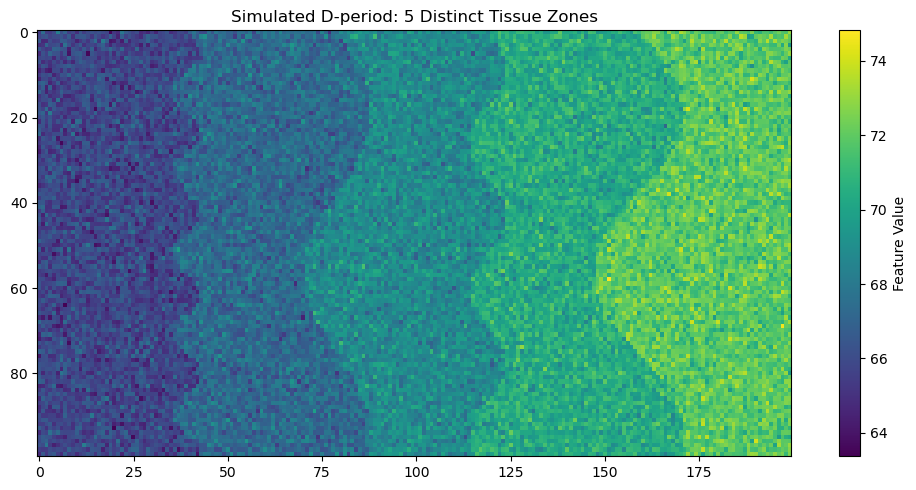

In [30]:
plt.figure(figsize=(10, 5))
plt.imshow(pseudo_dp, cmap='viridis', aspect='auto')
plt.title('Simulated D-period: 5 Distinct Tissue Zones')
plt.colorbar(label='Feature Value')
plt.tight_layout()
plt.show()

## 4. Kmeans model

Evaluate how standard K-means handles our simulated tissue data when forced to find a specific number of boundaries.
 * **Data Preparation**: Flatten the 2D grids into a 1D list and scale all four features so they have equal weight in the model.
 * **Experiment**: Run the algorithm three seperate times on the eaxct same data, strictly forcing it to find 3, 4 and 5 clusters.
 * **Goal**: Plot these three predictions side-by-side against the ground truth (with 5 zones) to visually demonstrate how standard K-means behaves-and strugles-when defining complex biological boundaries. 

K-means finished testing 3, 4, and 5 clusters!


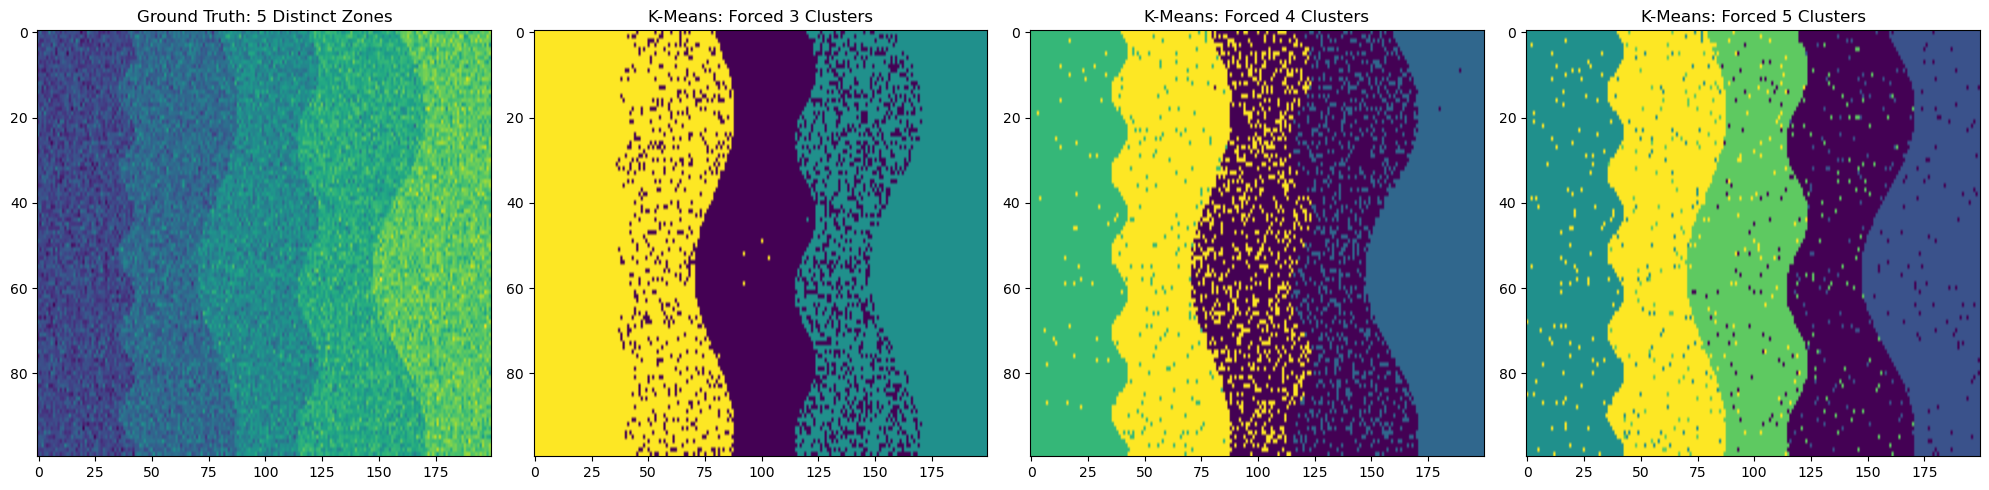

In [31]:
# Flatten and stack the features
flat_dp = pseudo_dp.reshape(-1, 1)
flat_wp = pseudo_wp.reshape(-1, 1)
flat_area = pseudo_area.reshape(-1, 1)
flat_pw = pseudo_pw.reshape(-1, 1)

X_pseudo = np.hstack((flat_dp, flat_area, flat_wp, flat_pw))

# Scale the data (each feature has its own order)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pseudo)

# Run the model in a loop for 3, 4 and 5 clusters
cluster_tests = [3, 4, 5]
kmeans_results = {} # Stores results in a dictionary

for k in cluster_tests:
    # Build and run the model in one line for each 'k'
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto').fit_predict(X_scaled)
    
    # Reshape the 1D labels back into our 100x200 image format and save it
    kmeans_results[k] = kmeans.reshape(100, 200)

print("K-means finished testing 3, 4, and 5 clusters!")

# Plot the results

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(pseudo_dp, cmap='viridis', aspect='auto')
axes[0].set_title("Ground Truth: 5 Distinct Zones")

axes[1].imshow(kmeans_results[3], cmap='viridis', aspect='auto')
axes[1].set_title("K-Means: Forced 3 Clusters")

axes[2].imshow(kmeans_results[4], cmap='viridis', aspect='auto')
axes[2].set_title("K-Means: Forced 4 Clusters")

axes[3].imshow(kmeans_results[5], cmap='viridis', aspect='auto')
axes[3].set_title("K-Means: Forced 5 Clusters")

plt.tight_layout()
plt.show()

## 5. HDBSCAN

#### DBSCAN
DBSCAN relies on two variables that work together
* $\epsilon$ (Epsilon): Imagine standing on a single pixel's data point and extending a tape measure in all directions. $\epsilon$ is the length of that tape measure. Any other points that fall within that radius are considered your "neighbors."
* $n$ (Min_Samples): This is the minimum number of neighbors you need inside your $\epsilon$ radius to officially be considered a "cluster." If your $\epsilon$ radius only catches 2 points, but $n$ is set to 5, you aren't a cluster—you are just labeled as "noise."

 In a single tissue sample, a severely fibrotic zone might have highly identical, tightly packed pixels (high density), while a healthy zone might have highly variable, loosely packed pixels (low density). If you set a small $\epsilon$, you completely miss the healthy zone. If you set a large $\epsilon$, the fibrotic zones blur together. You can't win.

 #### HDBSCAN

 The "H" stands for Hierarchical. HDBSCAN essentially runs DBSCAN across every single possible $\epsilon$ value at the exact same time and mathematically determines which clusters are the most stable. It completely removes the burden of guessing the $\epsilon$ radius. We only have to care about one primary variable:

 * min_cluster_size (The new $n$): This is the "Is this a real tissue zone or just a glitch?" threshold. It simply asks: What is the absolute smallest number of pixels that can exist together before you care about them?

 ##### Choosing the $n$

 Since teh grid size is 100x200 = 20.000 total pixels, and we know theres 5 regions:
 * **min_cluster_size=5**: too small and would detect a small region of noise as a new cluster
 * **min_cluster_size=10.000**: the cluster takes half the grid size
 
 I use **min_cluster_size** between 200 and 500 as a starting point


HDBSCAN autonomously detected 2 distinct clusters!


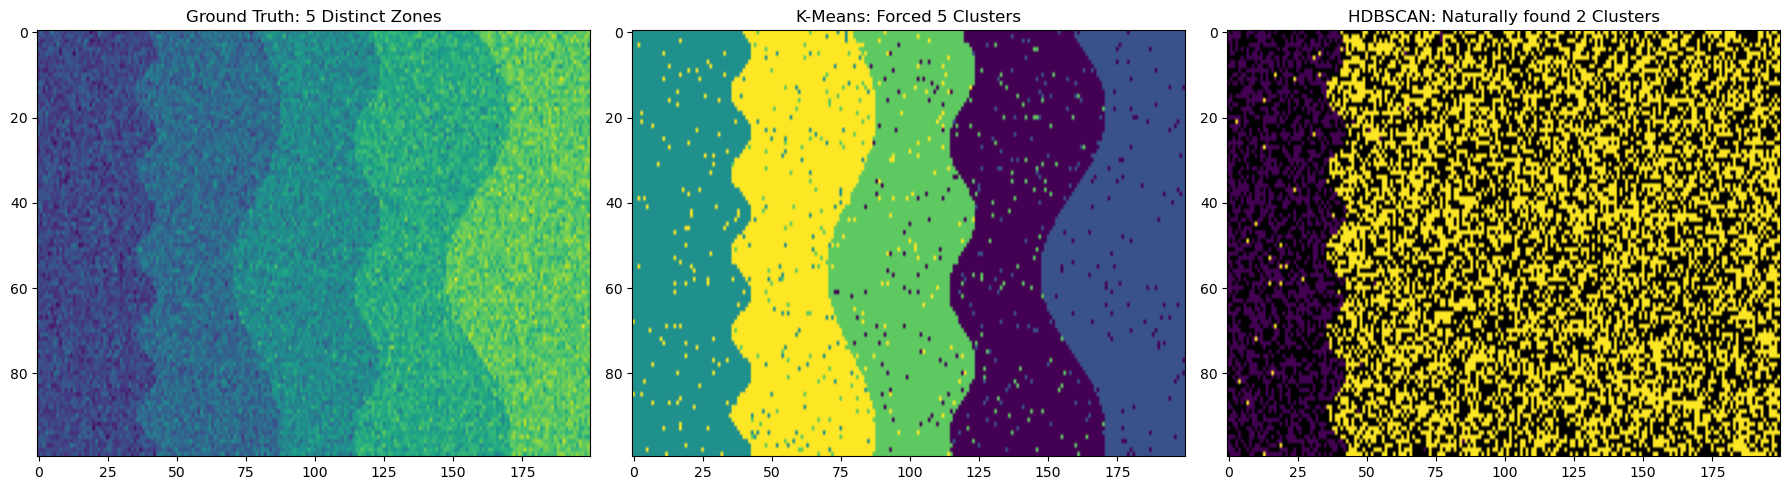

In [58]:
# 1. Run HDBSCAN
# We set min_cluster_size to 2000 and min_samples to 10.
hdb = hdbscan.HDBSCAN(min_cluster_size=300, min_samples=10)
hdb_labels = hdb.fit_predict(X_scaled)

# Calculate how many clusters it actually found (HDBSCAN labels noise as -1)
num_clusters_found = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
print(f"HDBSCAN autonomously detected {num_clusters_found} distinct clusters!")

# 2. Reshape the 1D labels back into our 100x200 image grid
seg_hdbscan = hdb_labels.reshape(100, 200)

# 3. Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(pseudo_dp, cmap='viridis', aspect='auto') # Ground Truth
axes[0].set_title("Ground Truth: 5 Distinct Zones")

axes[1].imshow(kmeans_results[5], cmap='viridis', aspect='auto') # Kmeans with 5 clusters
axes[1].set_title("K-Means: Forced 5 Clusters")

# HDBSCAN
# if HDBSCAN finds noise (-1), we can set a bad value color
cmap_hdb = plt.cm.viridis.copy()
cmap_hdb.set_under('black') # Noise pixels will show up as black

# vmin=0 forces any label below 0 (the -1 noise labels) to use the black 'under' color
# black represents the anomalies (noise) detected.
axes[2].imshow(seg_hdbscan, cmap=cmap_hdb, aspect='auto', vmin=0) 
axes[2].set_title(f"HDBSCAN: Naturally found {num_clusters_found} Clusters")

plt.tight_layout()
plt.show()